# Two RFF-MMD change point detectors

This notebook will do: 


  1. Sparse grid : dyadic 2^k windows searched by greedy recursion, finding an
                   unknown number of change points.
  2. Moving sum  : a single fixed-width window slid along the series (MOSUM).

Both return coarse intervals, then a shared post-processing step (`localise`)
pins the exact change-point index inside each interval.

The local statistic is the MMD between the two halves of a window, computed in
RFF feature space from a prefix-sum of the feature matrix (O(1) per window):

    stat(l, w) = ||sum_B - sum_A|| / sqrt(w)
               = sqrt(w)/2 * ||mean_B - mean_A||

               


### RFF

In [1]:
import numpy as np
import math
from math import sqrt, log, floor

class RFF:
    """
    Random Fourier Feature map for the Gaussian kernel K(x,y)=exp(-gamma||x-y||^2).

    Draws `rr` random frequencies omega_j ~ N(0, 2*gamma*I) and maps each point
    x to [sin(omega x), cos(omega x)] / sqrt(rr) in R^{2*rr}, so that the
    Euclidean inner product of two feature vectors approximates K(x, y).
    """

    def __init__(self, dd, rr, gamma, seed=0):
        """
        Args:
            dd    (int)   : data dimension (number of columns of X).
            rr    (int)   : number of random features; feature dimension is 2*rr.
            gamma (float) : Gaussian kernel bandwidth parameter.
            seed  (int)   : RNG seed for reproducible frequencies.
        """
        rng = np.random.default_rng(seed)
        self.omega = rng.normal(scale=np.sqrt(2 * gamma), size=(rr, dd))  # (rr, dd)
        self.rr = rr

    def zz(self, xx):
        """
        Map one point to its RFF feature vector.

        Args:
            xx (array, shape (dd,)) : a single data point.
        Returns:
            array, shape (2*rr,) : the feature vector [sin(proj), cos(proj)]/sqrt(rr).
        """
        proj = self.omega @ xx                       # (rr,)
        return np.concatenate([np.sin(proj), np.cos(proj)]) / np.sqrt(self.rr)


def med(XX):
    """
    Median heuristic for the kernel bandwidth.

    Computes H_n = median{ ||X_i - X_j||^2 : i < j }, the typical squared
    pairwise distance. A common choice is then gamma = 1 / H_n.

    Args:
        XX (array, shape (n, d)) : the data points.
    Returns:
        float : H_n, the median squared pairwise distance.
    """
    sq = np.sum((XX[:, None, :] - XX[None, :, :]) ** 2, axis=-1)  # all ||Xi-Xj||^2
    iu = np.triu_indices(XX.shape[0], k=1)           # pairs where i < j
    return np.median(sq[iu])

### Sparse Grid

In [2]:
def estimate_sigma(yy):
    """
    Estimate a noise scale via the MAD of first differences.

    Robust because only a few first differences straddle a change point.

    Args:
        yy (array, shape (n,)) : a one-dimensional series.
    Returns:
        float : the estimated noise standard deviation.
    """
    yy = np.asarray(yy, dtype=float)
    yy_diff = np.diff(yy)
    cp = 2
    scaled = yy_diff / np.sqrt(cp)
    sigma = np.median(np.abs(scaled - np.median(scaled))) * 1.4826
    return sigma


def get_thresh(nn, sigma, alpha):
    """
    Detection threshold used by the local tests.

    Args:
        nn    (int)   : series length.
        sigma (float) : noise scale from estimate_sigma().
        alpha (float) : sensitivity knob; larger alpha -> lower threshold ->
                        more detections. (Not a Type-I error rate.)
    Returns:
        float : the threshold sqrt(2.1 * sigma * log(nn) / alpha).
    """
    return sqrt(2.1 * sigma * (log(nn / alpha)))


def get_window_sizes(nn):
    """
    Dyadic window sizes W(k) = 2^k for k = 1 .. floor(log2(nn/2)).

    Args:
        nn (int) : series length.
    Returns:
        list[int] : window widths, ascending (finest first). Empty if nn < 4.
    """
    if nn < 4:
        return []
    kk_max = floor(math.log2(nn / 2))
    return [2 ** kk for kk in range(1, kk_max + 1)]


def generate_grid(ss, ee, nn):
    """
    Yield all (start, width) windows that fit inside the segment [ss, ee).

    Finest scale first, so a greedy consumer meets the narrowest windows first.

    Args:
        ss (int) : segment left bound (inclusive).
        ee (int) : segment right bound (exclusive).
        nn (int) : full series length (sets the dyadic scale set).
    Yields:
        (ll, ww) tuples : window start ll and width ww with ll+ww <= ee.
    """
    window_sizes = get_window_sizes(nn)
    for ww in window_sizes:
        for ll in range(ss, ee - ww + 1):
            yield (ll, ww)

###

In [3]:
def diff_statistic(Y_cumsum, ll, ww):
    """
    Local MMD statistic on the window [ll, ll+ww), split into two halves.

    Y_cumsum is the prefix sum of the RFF feature matrix, so the two half-sums
    are vectors and the statistic is the norm of their difference, scaled:

        ||sum_B - sum_A|| / sqrt(ww) = sqrt(ww)/2 * ||mean_B - mean_A||

    Args:
        Y_cumsum (array, shape (n+1, 2*rr)) : prefix sum of the feature matrix.
        ll (int) : window start index.
        ww (int) : window width.
    Returns:
        float : the (non-negative) MMD statistic for this window; 0 if ww < 2.
    """
    chunk = ww // 2
    if chunk == 0:
        return 0.0
    Y_bar_0 = Y_cumsum[ll + chunk]     - Y_cumsum[ll]            # first half sum
    Y_bar_1 = Y_cumsum[ll + 2 * chunk] - Y_cumsum[ll + chunk]    # second half sum

    numerator = np.linalg.norm(-Y_bar_0 + Y_bar_1)              # MMD (feature space)
    scale = sqrt(ww)
    return numerator / scale

### Search

In [4]:
def greedy_interval_search(Y_cumsum, ss, ee, nn, thresh, intervals):
    """
    Recursively find intervals that contain a significant change point.

    Scans the dyadic grid finest-first; on the first window whose statistic
    exceeds `thresh`, records that window as an interval and recurses on the
    left and right sub-segments. Mutates `intervals` in place.

    Args:
        Y_cumsum (array, shape (n+1, 2*rr)) : feature prefix sum.
        ss (int) : current segment left bound (inclusive).
        ee (int) : current segment right bound (exclusive).
        nn (int) : full series length.
        thresh (float) : detection threshold from get_thresh().
        intervals (list) : accumulator; each entry is a dict with
                           "start", "end", "stat".
    Returns:
        None (results are appended to `intervals`).
    """
    if (ee - ss) < 2:
        return
    detection = False
    for ll, ww in generate_grid(ss, ee, nn):
        stat = diff_statistic(Y_cumsum, ll, ww)
        if abs(stat) > thresh:
            intervals.append({
                "start": ll,
                "end":   ll + ww - 1,
                "stat":  round(float(stat), 4),
            })
            greedy_interval_search(Y_cumsum, ss, ll, nn, thresh, intervals)
            greedy_interval_search(Y_cumsum, ll + ww - 1, ee, nn, thresh, intervals)
            detection = True
        if detection:
            break
    return

### Post Processing

In [5]:
def localise(Y_cumsum, tt1, tt2, min_side=1):
    """
    Pin the exact change point inside a detected interval [tt1, tt2).

    Sweeps every split kk and maximises the weighted MMD
    ||mean_A - mean_B|| * sqrt(kk*(mm-kk)/mm), where mm = tt2 - tt1. This is the
    LR change-in-mean statistic generalised to RFF feature space.

    Args:
        Y_cumsum (array, shape (n+1, 2*rr)) : feature prefix sum.
        tt1 (int) : interval left bound (inclusive).
        tt2 (int) : interval right bound (exclusive).
        min_side (int) : minimum points on each side of the split (default 1).
    Returns:
        (cp, stat) : cp = tt1 + best_kk + 1 (first index of the second segment),
                     stat = the weighted MMD at that split.
    """
    mm = tt2 - tt1
    if mm < 2:
        return tt1, 0.0
    best_stat, best_kk = -1.0, mm // 2
    for kk in range(min_side, mm - min_side + 1):
        mean_A = (Y_cumsum[tt1 + kk] - Y_cumsum[tt1]) / kk
        mean_B = (Y_cumsum[tt2]      - Y_cumsum[tt1 + kk]) / (mm - kk)
        stat = np.linalg.norm(mean_A - mean_B) * sqrt(kk * (mm - kk) / mm)
        if stat > best_stat:
            best_stat, best_kk = stat, kk
    return tt1 + best_kk + 1, best_stat


def _build_feature_cumsum(XX, rr, gamma, seed):
    """
    Shared preprocessing: coerce input, pick bandwidth, RFF map, prefix sum.

    Args:
        XX (array, shape (n,) or (n, d)) : input data.
        rr (int) : number of random features.
        gamma (float or None) : kernel bandwidth; if None, uses 1/med(XX).
        seed (int) : RNG seed for the RFF map.
    Returns:
        XX       (array, shape (n, d)) : the data as a 2-D float array.
        nn       (int)                 : number of points.
        gamma    (float)               : the bandwidth actually used.
        Y_cumsum (array, (n+1, 2*rr))  : prefix sum of the feature matrix.
    """
    XX = np.asarray(XX, dtype=float)
    if XX.ndim == 1:
        XX = XX[:, None]
    nn = XX.shape[0]
    if gamma is None:
        gamma = 1.0 / med(XX)
    rff = RFF(dd=XX.shape[1], rr=rr, gamma=gamma, seed=seed)
    ZZ = np.array([rff.zz(XX[ii]) for ii in range(nn)])
    Y_cumsum = np.zeros((nn + 1, ZZ.shape[1]))
    np.cumsum(ZZ, axis=0, out=Y_cumsum[1:])
    return XX, nn, gamma, Y_cumsum

### Sparse grid CP

In [6]:
def detect_sparse(XX, alpha=1, rr=500, gamma=None, seed=42):
    """
    Sparse-grid detector: dyadic greedy search + post-processing.

    Args:
        XX (array, shape (n,) or (n, d)) : input series.
        alpha (float) : sensitivity knob (see get_thresh); larger -> more fires.
        rr (int) : number of random features.
        gamma (float or None) : kernel bandwidth; None -> median heuristic.
        seed (int) : RNG seed for the RFF map.
    Returns:
        dict with:
            "intervals" : list of dicts, each {"start","end","stat","cp","cp_stat"}.
            "cps"       : list[int], the post-processed change-point indices.
            "thresh"    : float, the detection threshold used.
            "sigma"     : float, the estimated noise scale.
            "gamma"     : float, the bandwidth used.
    """
    XX, nn, gamma, Y_cumsum = _build_feature_cumsum(XX, rr, gamma, seed)
    sigma = estimate_sigma(XX[:, 0])
    thresh = get_thresh(nn, sigma, alpha)

    intervals = []
    greedy_interval_search(Y_cumsum, 0, nn, nn, thresh, intervals)
    intervals = sorted(intervals, key=lambda x: x["start"])

    for iv in intervals:                                   # post-process each
        iv["cp"], cp_stat = localise(Y_cumsum, iv["start"], iv["end"] + 1)
        iv["cp_stat"] = round(cp_stat, 4)

    return {"intervals": intervals, "cps": [iv["cp"] for iv in intervals],
            "thresh": round(thresh, 4), "sigma": round(float(sigma), 4),
            "gamma": round(float(gamma), 6)}


### Moving Sum CP

In [7]:
def detect_mosum(XX, alpha=1, rr=500, gamma=None, seed=42, HH=128):
    """
    Moving-sum detector: a single fixed window slid along the series.

    Slides a window of width HH; on a detection, records the window, localises
    the change point inside it, and jumps past the window; otherwise advances
    by one (overlap-by-one).

    Args:
        XX (array, shape (n,) or (n, d)) : input series.
        alpha (float) : sensitivity knob (see get_thresh).
        rr (int) : number of random features.
        gamma (float or None) : kernel bandwidth; None -> median heuristic.
        seed (int) : RNG seed for the RFF map.
        HH (int) : the fixed window width. Too small misses subtle/wide changes;
                   too large smears nearby changes.
    Returns:
        dict with:
            "intervals" : list of dicts, each {"start","end","w","cp","cp_stat"}.
            "cps"       : list[int], the post-processed change-point indices.
            "thresh"    : float, the detection threshold used.
            "sigma"     : float, the estimated noise scale.
            "gamma"     : float, the bandwidth used.
    """
    XX, nn, gamma, Y_cumsum = _build_feature_cumsum(XX, rr, gamma, seed)
    sigma = estimate_sigma(XX[:, 0])
    thresh = get_thresh(nn, sigma, alpha)

    intervals = []
    tt = 0
    while tt + HH <= nn:
        if diff_statistic(Y_cumsum, tt, HH) > thresh:
            cp, cp_stat = localise(Y_cumsum, tt, tt + HH)
            intervals.append({"start": tt, "end": tt + HH - 1, "w": HH,
                              "cp": cp, "cp_stat": round(cp_stat, 4)})
            tt = tt + HH + 1                           # jump past the window
        else:
            tt += 1                                    # slide, overlap by one

    return {"intervals": intervals, "cps": [iv["cp"] for iv in intervals],
            "thresh": round(thresh, 4), "sigma": round(float(sigma), 4),
            "gamma": round(float(gamma), 6)}


### Data generation

In [8]:
# Fixed segmentation from Arlot, Celisse & Harchaoui (2019), Section 6.1:
# n = 1000, 11 segments, 10 change points.
tau_star = [100, 130, 220, 320, 370, 520, 620, 740, 790, 870]
_N = 1000
_bounds = [0] + tau_star + [_N]

# Distribution names, index-aligned with the draw() branches below.
S1_NAMES = ["Bi(10,0.2)", "Neg_Bi(3,0.7)", "Hyper(10,5,2)", "Normal(2.5,0.25)",
            "gamma(0.5,5)", "Weibull(5,2)", "Pareto(1.5,3)"]
S2_NAMES = ["Bernoulli(0.5)", "Normal(0.5,0.25)", "Exp(0.5)"]


def _labels(n_dists, rng):
    """
    Random segment labels following the paper's selection rule.

    S_1 is uniform over {0..n_dists-1}; each S_{l+1} is uniform over that set
    minus S_l, so consecutive segments never share a distribution.

    Args:
        n_dists (int) : number of candidate distributions.
        rng (Generator) : a numpy random generator.
    Returns:
        list[int] : one distribution index per segment.
    """
    out = [rng.integers(n_dists)]
    for _ in range(1, len(_bounds) - 1):
        out.append(rng.choice([d for d in range(n_dists) if d != out[-1]]))
    return out


def make_scenario1(seed=0):
    """
    Scenario 1: real-valued data with changing (mean, variance).

    Seven distributions (Table B.1), one drawn per segment. The mean usually
    shifts across boundaries -> the easier case.

    Args:
        seed (int) : RNG seed (fixes which distribution lands in each segment).
    Returns:
        X         (array, shape (1000, 1)) : the generated series.
        tau_star  (list[int])              : the 10 true change points.
        seg_names (list[str])              : distribution name per segment.
    """
    rng = np.random.default_rng(seed)
    labels = _labels(7, rng)

    def draw(dist, size):
        if dist == 0: return rng.binomial(10, 0.2, size).astype(float)
        if dist == 1: return rng.negative_binomial(3, 0.7, size).astype(float)
        if dist == 2: return rng.hypergeometric(5, 5, 2, size).astype(float)
        if dist == 3: return rng.normal(2.5, 0.5, size)
        if dist == 4: return rng.gamma(0.5, 5.0, size)
        if dist == 5: return 5.0 * rng.weibull(2.0, size)
        if dist == 6: return 1.5 * (1.0 + rng.pareto(3.0, size))

    xx = np.empty(_N)
    for s, e, lab in zip(_bounds[:-1], _bounds[1:], labels):
        xx[s:e] = draw(lab, e - s)
    seg_names = [S1_NAMES[d] for d in labels]
    return xx[:, None], list(tau_star), seg_names


def make_scenario2(seed=0):
    """
    Scenario 2: constant mean 0.5 and variance 0.25; only the shape changes.

    Three distributions (Bernoulli, Gaussian, exponential), one per segment,
    all sharing mean 0.5 and variance 0.25 -> the hard, shape-only case.

    Args:
        seed (int) : RNG seed (fixes which distribution lands in each segment).
    Returns:
        X         (array, shape (1000, 1)) : the generated series.
        tau_star  (list[int])              : the 10 true change points.
        seg_names (list[str])              : distribution name per segment.
    """
    rng = np.random.default_rng(seed)
    labels = _labels(3, rng)

    def draw(dist, size):
        if dist == 0: return rng.binomial(1, 0.5, size).astype(float)
        if dist == 1: return rng.normal(0.5, 0.5, size)
        if dist == 2: return rng.exponential(0.5, size)

    xx = np.empty(_N)
    for s, e, lab in zip(_bounds[:-1], _bounds[1:], labels):
        xx[s:e] = draw(lab, e - s)
    seg_names = [S2_NAMES[d] for d in labels]
    return xx[:, None], list(tau_star), seg_names

### Graph

Scenario 1: true=[100, 130, 220, 320, 370, 520, 620, 740, 790, 870]
   segments: gamma(0.5,5) -> Weibull(5,2) -> Bi(10,0.2) -> Weibull(5,2) -> Hyper(10,5,2) -> gamma(0.5,5) -> Normal(2.5,0.25) -> Neg_Bi(3,0.7) -> Pareto(1.5,3) -> Bi(10,0.2) -> Hyper(10,5,2)
   sparse cps (3): [321, 521, 864]
   mosum  cps (2): [321, 521]


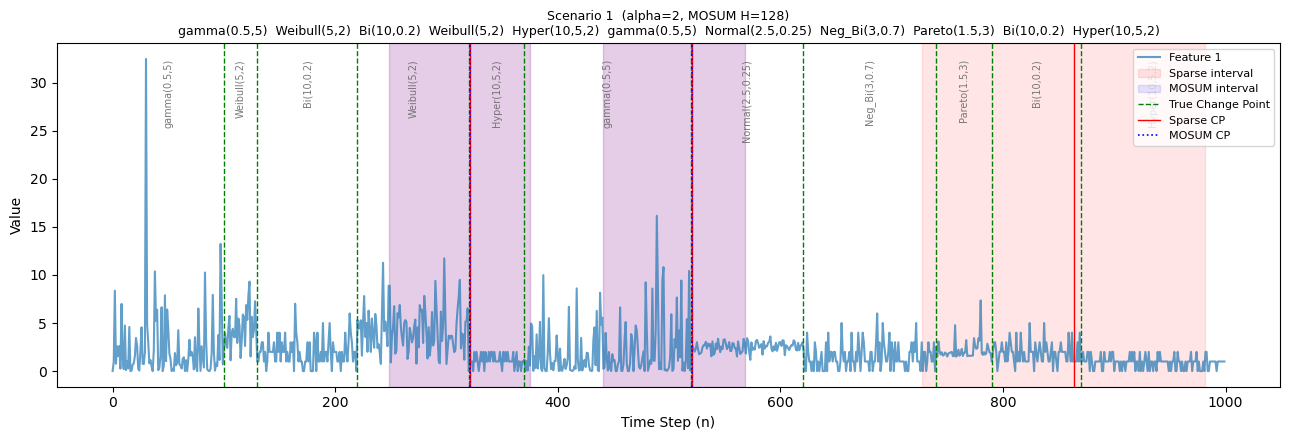

Scenario 2: true=[100, 130, 220, 320, 370, 520, 620, 740, 790, 870]
   segments: Exp(0.5) -> Normal(0.5,0.25) -> Bernoulli(0.5) -> Exp(0.5) -> Bernoulli(0.5) -> Exp(0.5) -> Normal(0.5,0.25) -> Bernoulli(0.5) -> Exp(0.5) -> Bernoulli(0.5) -> Normal(0.5,0.25)
   sparse cps (3): [131, 369, 612]
   mosum  cps (2): [131, 369]


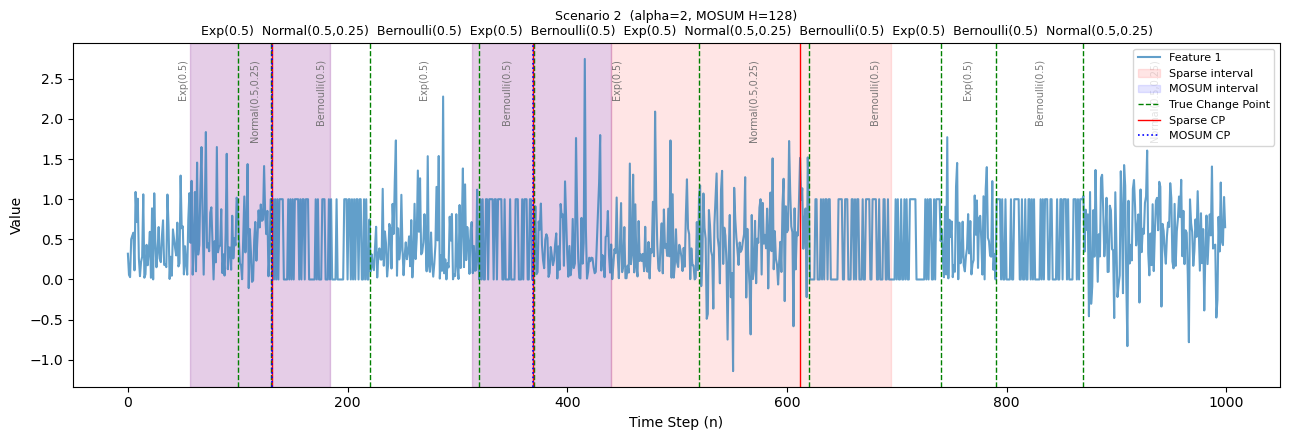

In [10]:

if __name__ == "__main__":
    import sys
    import matplotlib.pyplot as plt
    sys.setrecursionlimit(20000)
 
    alpha = 2      # sensitivity; higher = fewer fires (alpha=5 over-fires on S2)
    HH = 128       # MOSUM window width
 
    for scen, gen in [("Scenario 1", make_scenario1),
                      ("Scenario 2", make_scenario2)]:
        X, true_cps, seg_names = gen(seed=5)
 
        sparse = detect_sparse(X, alpha=alpha, rr=500, seed=42)
        mosum  = detect_mosum(X, alpha=alpha, rr=500, seed=42, HH=HH)
        sparse_cps = sorted(sparse["cps"])
        mosum_cps  = sorted(mosum["cps"])
 
        print(f"{scen}: true={true_cps}")
        print(f"   segments: {' -> '.join(seg_names)}")
        print(f"   sparse cps ({len(sparse_cps)}): {sparse_cps}")
        print(f"   mosum  cps ({len(mosum_cps)}): {mosum_cps}")
 
        plt.figure(figsize=(13, 4.5))
        plt.plot(X[:, 0], label='Feature 1', alpha=0.7)
        if X.shape[1] > 1:
            plt.plot(X[:, 1], label='Feature 2', alpha=0.7)
 
        # shaded detection intervals (behind the CP lines)
        for i, iv in enumerate(sparse["intervals"]):
            plt.axvspan(iv["start"], iv["end"], color='r', alpha=0.10,
                        label='Sparse interval' if i == 0 else None)
        for i, iv in enumerate(mosum["intervals"]):
            plt.axvspan(iv["start"], iv["end"], color='b', alpha=0.10,
                        label='MOSUM interval' if i == 0 else None)
 
        for i, t in enumerate(true_cps):
            plt.axvline(x=t, color='g', linestyle='--', lw=1,
                        label='True Change Point' if i == 0 else None)
        for i, c in enumerate(sparse_cps):
            plt.axvline(x=c, color='r', linestyle='-', lw=1,
                        label='Sparse CP' if i == 0 else None)
        for i, c in enumerate(mosum_cps):
            plt.axvline(x=c, color='b', linestyle=':', lw=1.2,
                        label='MOSUM CP' if i == 0 else None)
 
        edges = [0] + true_cps + [len(X)]
        ymax = X[:, 0].max()
        for s, e, name in zip(edges[:-1], edges[1:], seg_names):
            plt.text((s + e) / 2, ymax, name, rotation=90, ha='center',
                     va='top', fontsize=7, color='dimgray', alpha=0.9)
 
        plt.title(f"{scen}  (alpha={alpha}, MOSUM H={HH})\n"
                  + "  ".join(seg_names), fontsize=9)
        plt.xlabel("Time Step (n)")
        plt.ylabel("Value")
        plt.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()
 